![Redis](https://redis.io/wp-content/uploads/2024/04/Logotype.svg?auto=webp&quality=85,75&width=120)

# Advanced Semantic Routing - Improving Routing Performance
In many experiments, we use benchmark datasets to demonstrate the classification capabilities of the semantic router. The semantic router performs well for such well-curated sets because the exampels are well aligned and routes are clearly defined.

However, in practice, route definitions are often hand-authored and only weakly specified. Using human expertise for route definitions upsteam might result in poor quality if:
- examples are written from intuition (and not from real users)
- examples are sparse
- route boundaries are fuzzy
- bias is introduced due to human decision (different intent definition between different people)

In this notebook, we will explore various strategies for improving router performance in some cases where route quality is not guaranteed. These strategies include:
- simply using another embedding model
- using the LLM upstream for augmenting the set of route references
- using the LLM as a fallback classifier when the performance of the semantic router starts to degrade (albeit with some tradeoffs).

## Before we get started
To understand more about semantic routing, please refer to the following: 
- [RedisVL Semantic Routing](https://docs.redisvl.com/en/latest/user_guide/08_semantic_router.html) - A guide on how to use the SemanticRouter from RedisVL
- [Source Code (GitHub)](https://github.com/redis/redis-vl-python#semantic-routing) - Source code for the implementation.
- [Embeddings](https://redis.io/blog/why-vector-embeddings-are-here-to-stay/) - A blogpost about embeddings and what they are used for.


## Let's Begin!
<a href="https://colab.research.google.com/github/redis-developer/redis-ai-resources/blob/main/python-recipes/semantic-router/02_advanced_semantic_routing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

First, let's download the required packages and set our API keys:

In [ ]:
%pip install -q "redisvl[sentence-transformers]>=0.6.0" datasets scikit-learn openai matplotlib 

### Install Redis 

#### For Colab
Use the shell script below to download, extract, and install Redis Stack directly from the Redis package archive.

In [ ]:
# NBVAL_SKIP
# Colab only: install and start Redis Stack.
%%sh
sudo apt-get install -y -qq lsb-release curl gpg > /dev/null
curl -fsSL https://packages.redis.io/gpg | sudo gpg --dearmor -o /usr/share/keyrings/redis-archive-keyring.gpg
sudo chmod 644 /usr/share/keyrings/redis-archive-keyring.gpg
echo "deb [signed-by=/usr/share/keyrings/redis-archive-keyring.gpg] https://packages.redis.io/deb $(lsb_release -cs) main" | sudo tee /etc/apt/sources.list.d/redis.list
sudo apt-get update -qq > /dev/null
sudo apt-get install -y -qq redis > /dev/null

redis-server --version
redis-server --daemonize yes --loadmodule /usr/lib/redis/modules/redisearch.so

#### For Alternative Environments
There are many ways to get the necessary redis-stack instance running
1. On cloud, deploy a [FREE instance of Redis in the cloud](https://redis.com/try-free/). Or, if you have your
own version of Redis Enterprise running, that works too!
2. Per OS, [see the docs](https://redis.io/docs/latest/operate/oss_and_stack/install/install-stack/)
3. With docker: `docker run -d --name redis-stack-server -p 6379:6379 redis/redis-stack-server:latest`

### Define the Redis Connection URL

By default this notebook connects to the local instance of Redis Stack. **If you have your own Redis Enterprise instance** - replace REDIS_PASSWORD, REDIS_HOST and REDIS_PORT values with your own.

In [3]:
import os
from redis import Redis

# Replace values below with your own if using Redis Cloud instance
REDIS_HOST = os.getenv("REDIS_HOST", "localhost") # ex: "redis-18374.c253.us-central1-1.gce.cloud.redislabs.com"
REDIS_PORT = os.getenv("REDIS_PORT", "6379")      # ex: 18374
REDIS_PASSWORD = os.getenv("REDIS_PASSWORD", "")  # ex: "1TNxTEdYRDgIDKM2gDfasupCADXXXX"

# If SSL is enabled on the endpoint, use rediss:// as the URL prefix
REDIS_URL = f"redis://:{REDIS_PASSWORD}@{REDIS_HOST}:{REDIS_PORT}"

client = Redis.from_url(REDIS_URL)
client.ping()
client.flushall()

True

## Imports

In [4]:
import asyncio
import json
import getpass
import random
from collections import defaultdict
from pprint import pprint, pformat
import warnings
warnings.filterwarnings("ignore")

from openai import AsyncOpenAI, OpenAI
from redisvl.extensions.router import Route, SemanticRouter
from redisvl.utils.vectorize import HFTextVectorizer

random.seed(123)

## API keys

In [5]:
# NBVAL_SKIP
# OpenAI API key is required for LLM calls
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY") or getpass.getpass("OpenAI API key: ")
openai_client = AsyncOpenAI(api_key=OPENAI_API_KEY)

## Data setup

We get our sample data from the [CLINC dataset](https://huggingface.co/datasets/DeepPavlov/clinc150). 
In our setup, we simulate a real-life scenario where we have identified a bunch of routes for intent classification, but is limited by a lack of high-quality references for each route. 

In this scenario, we attempt to perform intent classification on a simulated banking chatbot, using intents from the CLINC dataset related to `balance`, `transactions`, `transfer`, `pay_bill`, `bill_due`, `card_declined`, `report_fraud`, `freeze_account`, `credit_score`, `direct_deposit`. The dataset represents actual queries that we might expect from a deployed real-life production chatbot.

In [6]:
from datasets import load_dataset
data = load_dataset("clinc_oos", "plus")

In [7]:
intents = [
    "balance",
    "transactions",
    "transfer",
    "pay_bill",
    "bill_due",
    "card_declined",
    "report_fraud",
    "freeze_account",
    "credit_score",
    "direct_deposit",
]

In [8]:
# Create a subset of data only with the intents we are interested in
intent_names = data['train'].features['intent'].names
intent_ids = [intent_names.index(intent) for intent in intents]

data_subset = data.filter(lambda example: example['intent'] in intent_ids)

# View a sample of the data subset
{
    split: {
        'rows': len(data_subset[split]),
        'sample_texts': data_subset[split]['text'][:3],
        'sample_intents': [intent_names[i] for i in data_subset[split]['intent'][:3]],
    }
    for split in data_subset
}

{'train': {'rows': 1000,
  'sample_texts': ['i need $20000 transferred from my savings to my checking',
   'complete a transaction from savings to checking of $20000',
   'transfer $20000 from my savings account to checking account'],
  'sample_intents': ['transfer', 'transfer', 'transfer']},
 'validation': {'rows': 200,
  'sample_texts': ['transfer ten dollars from my wells fargo account to my bank of america account',
   'take one hundred and fifty bucks from my wells fargo checking account and put it in my wells fargo savings account',
   'put one hundred and seventy five bucks in my wells fargo checking account from my citibank savings account'],
  'sample_intents': ['transfer', 'transfer', 'transfer']},
 'test': {'rows': 300,
  'sample_texts': ['can you please provide me with assistance in moving money from one account to another',
   'i would like help moving money between accounts',
   'can you assist me in moving money from one account to another'],
  'sample_intents': ['transf

In [9]:
# Group the dataset by intent classes
train_by_intent = defaultdict(list)

for example in data_subset['train']:
    intent_name = intent_names[example['intent']]
    train_by_intent[intent_name].append(example['text'])

train_by_intent = dict(train_by_intent)
pprint(train_by_intent)

{'balance': ['savings account balance at chase bank please',
             'check chase bank for my checking balance',
             'what is my checking account balance at chase',
             'i want my checking balance at chase',
             "what's my savings balance at chase",
             'do i have enough money in my chime bank account to take ashley '
             'to the movies tuesday',
             'check my visa account and see if i have enough money for dinner '
             'tonight',
             'is tehre enough in my bluebird account for groceries this week',
             'do i have enough in my sears account to buy a new dishwasher',
             'is there enough money in my discover account for a new pair of '
             'jeans',
             'what is the total of my bank accounts',
             'what is in my bank accounts',
             'what is the balance on my bank accounts',
             'what is remaining in my bank acccounts',
             'how much money is

By grouping the dataset by intent classes, it is easier to visualize how each route and their respective references might look like.

## Helper Functions

We define some reusable helper functions to measure the effectiveness of our strategies.

In [10]:
import numpy as np
from time import perf_counter

### For profiling latency
class profile_block:
    """Context manager for profiling code block and measuring latency"""
    def __init__(self, label="Block"):
        self.label = label
        self.elapsed = None

    def __enter__(self):
        self._start = perf_counter()
        return self

    def __exit__(self, exc_type, exc, tb):
        self.elapsed = perf_counter() - self._start

def get_router_classification(router, text):
    pred = router(statement=text)
    return {"name": pred.name,
            "distance": pred.distance}

def evaluate_classification(classifier, split="test"):
    """Evaluate a classifier on a CLINC split."""
    eval_split = data_subset[split]

    num_correct = 0
    total_distance = 0.0
    num_distance_values = 0
    latencies_ms = []
    case_results = []
    num_examples = len(eval_split)

    for example in eval_split:
        text = example['text']
        true_intent = intent_names[example['intent']]

        with profile_block('classification_call') as timer:
            result = classifier(text)
            
        latencies_ms.append(timer.elapsed * 1000)
        
        predicted_intent = result['name']
        distance = result['distance']

        is_correct = predicted_intent == true_intent

        if is_correct:
            num_correct += 1

        if distance is not None:
            total_distance += distance
            num_distance_values += 1

        case_results.append({
            'text': text,
            'true_intent': true_intent,
            'predicted_intent': predicted_intent,
            'distance': distance,
            'is_correct': is_correct,
        })

    aggregate_results = {
        'num_examples': num_examples,
        'accuracy': round(num_correct / num_examples, 4),
        "avg_latency": round(float(np.mean(latencies_ms)), 2),
        "p95_latency": round(float(np.percentile(latencies_ms, 95)), 2),
        "p99_latency": round(float(np.percentile(latencies_ms, 99)), 2),
    }

    if num_distance_values:
        aggregate_results['avg_distance'] = round(total_distance / num_distance_values, 4)

    per_test_case_results = {
        'per_test_case': case_results,
    }

    return aggregate_results, per_test_case_results


## Part I: Choice of embedding model

### Strategy 1: Pick an embedding model that better suits your use case

Sometimes, simply picking another embedding model (either an open source one or even better, a finetuned one) might pay good dividends in improving routing performance.

#### Scenario setup

For this scenario, we'll be creating semantic routers using routes and references from the training dataset, and exploring how we can improve routing performance simply by picking another embedding model.

In [11]:
scenario_routes = [Route(name=intent, references=references) 
                   for intent, references in train_by_intent.items()
                   ]

#### Create a basic router

We create a basic router as a baseline for this scenario using the `HFTextVectorizer` class from RedisVL, leveraging on the pre-trained embedding models provided by the `sentence-transformers` library. (Refer to this [link](https://sbert.net/docs/sentence_transformer/pretrained_models.html) for the list of available embedding models provided by the library.)

For the baseline, we use the `sentence-transformers/all-MiniLM-L6-v2` model.

In [12]:
basic_router_minilm = SemanticRouter(
    name='basic-router-miniLM-L6',
    routes=scenario_routes,
    vectorizer=HFTextVectorizer(model="sentence-transformers/all-MiniLM-L6-v2"),
    redis_client=client,
    overwrite=True,
)

In [13]:
basic_router_minilm_metrics, basic_router_minilm_per_test_case = evaluate_classification(
    lambda text: get_router_classification(basic_router_minilm, text))

print(f"Accuracy on MiniLM-L6 embedding model: {100*basic_router_minilm_metrics['accuracy']:.2f}%")

Accuracy on MiniLM-L6 embedding model: 86.67%


#### Picking a different embedding model

Now, we pick a different model. `sentence-transformers` provides us with `sentence-transformers/all-mpnet-base-v2`, which scores the highest on their performance benchmark.

This is also the embedding model used by `HFTextVectorizer` by default.

In [14]:
basic_router_mpnet = SemanticRouter(
    name='basic-router-mpnet',
    routes=scenario_routes,
    vectorizer=HFTextVectorizer(model="sentence-transformers/all-mpnet-base-v2"),
    redis_client=client,
    overwrite=True,
)

In [15]:
basic_router_mpnet_metrics, basic_router_mpnet_per_test_case = evaluate_classification(
    lambda text: get_router_classification(basic_router_mpnet, text))

print(f"Accuracy on mpnet embedding model: {100*basic_router_mpnet_metrics['accuracy']:.2f}%")

Accuracy on mpnet embedding model: 92.67%


By simply picking a "better" embedding model, we have managed to improve the routing accuracy from 86.67% to 92.67%. Imagine how much the performance would increase by if we use a finetuned embedding model!

## Part II : Bootstrapping better Semantic Routes

### Strategy 2: LLM-based data augmentation

In practice, we might be unable to get our hands on references that represent the semantic space of each intent well. This can happen due to lack of access to (human) expert generation of references, especially if there are many intents to generate representative references for.

A strategy we can employ here is to use an LLM to generate synthetic data to augment the current set of references.

#### Scenario setup

To simulate this scenario, we downsample the CLINC dataset to obtain 3 labelled references per intent. These samples are of high-quality, similar to what a human expert might curate for a semantic router.

In [16]:
num_samples = 3

scenario_subset = {intent: random.sample(references, num_samples) 
                   for intent, references in train_by_intent.items()
                   }
pprint(scenario_subset)

{'balance': ['what is my bank balance for all accounts',
             "what's my bank balance",
             'perform a search for my most recent balance on my amex account'],
 'bill_due': ['give me the date my bill is due',
              'i would like to know when the bill is due',
              'i need to know the due date for my credit card'],
 'card_declined': ['i was at zales trying to buy a ring and my card got '
                   'declined',
                   'can you tell me why my card was declined',
                   'why did my card not get accepted'],
 'credit_score': ['can you find my credit score',
                  'i wanna know my credit rating now',
                  'lets look up my credit score'],
 'direct_deposit': ['let me set up direct deposit for this',
                    "i'd like to set up a direct deposit for my paycheck",
                    'can you teach me how to set up direct deposit, or show me '
                    'who can'],
 'freeze_account': ['c

In [17]:
scenario_routes = [Route(name=intent, references=references) 
                   for intent, references in scenario_subset.items()
                   ]

#### Basic semantic router behaviour on limited data

In [18]:
# Set up a basic semantic router
scenario_router_base = SemanticRouter(
    name='base-router-limited-data',
    routes=scenario_routes,
    vectorizer=HFTextVectorizer(),
    redis_client=client,
    overwrite=True,
)

In [19]:
scenario_router_metrics, scenario_router_per_test_case = evaluate_classification(
    lambda text: get_router_classification(scenario_router_base, text))

print(f"Accuracy on basic router (with limited data): {100*scenario_router_metrics['accuracy']:.2f}%")

Accuracy on basic router (with limited data): 83.00%


With just 3 references per intent, the base semantic router achieves an accuracy of 83%.

#### Augmenting route references 
using LLM-generated synthetic data 

In [20]:
# NBVAL_SKIP
synthetic_reference_prompt = f"""
You are helping generate synthetic route references for a semantic router.

Generate valid JSON with this schema:
{{
  \"transfer\": [\"...\"],
  \"balance\": [\"...\"],
  \"freeze_account\": [\"...\"],
  \"transactions\": [\"...\"],
  \"pay_bill\": [\"...\"],
  \"credit_score\": [\"...\"],
  \"bill_due\": [\"...\"],
  \"report_fraud\": [\"...\"],
  \"direct_deposit\": [\"...\"],
  \"card_declined\": [\"...\"]
}}

Requirements:
- Generate only route references, not evaluation pairs.
- Keep examples stylistically similar to the existing references.
- Make them diverse and realistic.
- Return only valid JSON.
"""

synthetic_reference_user_input = "Generate 20 new references per intent. Return only valid JSON."

response = await openai_client.responses.create(
        model="gpt-5.4",
        instructions=synthetic_reference_prompt,
        input=synthetic_reference_user_input,
        reasoning={"effort": "low"},
        text={"verbosity": "low"},
    )

synthetic_generated_references = json.loads(response.output_text)
pprint(synthetic_generated_references)


{'balance': ["What's my checking balance?",
             'Show my account balance',
             'How much money do I have in savings?',
             'Check my available balance',
             "What's left in my account?",
             'Tell me my current balance',
             'View balance for account ending in 4432',
             'How much is in my checking right now?',
             'Get my savings balance',
             'Show available funds',
             'What is my ledger balance?',
             'Check the balance on my joint account',
             'See my account totals',
             'Do I have enough money in checking?',
             'Display my balances',
             'How much cash do I have available?',
             'I want to see my current account balance',
             'Balance for my student account',
             'Let me know my available amount',
             "What's the balance on my main account?"],
 'bill_due': ['When is my credit card bill due?',
              "W

The LLM is able to generate route references that are quite similar to the original ones from the dataset.

In [ ]:
# NBVAL_SKIP
augmented_route_references = {intent: references + synthetic_generated_references[intent] 
                              for intent, references in scenario_subset.items()
                              }

scenario_routes_augmented = [Route(name=intent, references=references) 
                            for intent, references in augmented_route_references.items()
                            ]

#### Semantic router performance with augmented route references

In [ ]:
# NBVAL_SKIP
# Set up a basic semantic router
scenario_router_augmented = SemanticRouter(
    name='llm-augmented-banking-router',
    routes=scenario_routes_augmented,
    vectorizer=HFTextVectorizer(),
    redis_client=client,
    overwrite=True,
)

In [ ]:
# NBVAL_SKIP
scenario_router_augmented_metrics, scenario_router_augmented_per_test_case = evaluate_classification(
    lambda text: get_router_classification(scenario_router_augmented, text)
)

print(f"Accuracy on basic router (with LLM-augmented data): {100*scenario_router_augmented_metrics['accuracy']:.2f}%")

Accuracy on basic router (with LLM-augmented data): 89.33%


By generating synthetic references for each route using an LLM, we have managed to push the accuracy up to 89.33%.

Note: for this strategy, few-shot prompting could be used to guide the LLM's generation. However, it might result in less effective data augmentation if the LLM-generated references are very similar to the original references. The idea is to get the LLM to generate synthetic references that better define the semantic space of each intent, rather than to generate similar references to those we already have.

### Strategy 3: Bootstrapping intent routes using LLM

In practice, even if we have abundant references, we might not have access to human experts to classify them into their respective routes. When this happens, a strategy we can adopt is simply to use the LLM as a temporary classifier. 

In this scenario, we have identified route definitions and a bunch of unclassified references from our production environment. We use an LLM to generate labels for these unlabelled references, and then use this pseudo-labelled dataset to build our semantic router. This effectively bootstraps a labelled dataset using an LLM, since we generate training data from unlabelled inputs.

This method is a practical alternative when manually labelling route references is expensive, because the LLM acts like a strong zero-shot classifier to generate higher quality reference labels for the router.

#### Scenario setup

For this scenario, we sample the CLINC dataset to obtain a few references, which represent unclassified samples from production.

In [24]:
from itertools import chain
num_samples = 20

scenario_references_unclassified = [random.sample(references, num_samples) for references in train_by_intent.values()]
scenario_references_unclassified = list(chain.from_iterable(scenario_references_unclassified))
pprint(scenario_references_unclassified)

['transfer 200 dollars from paypal to savings',
 'send money to another account',
 'please transfer $50 to my checking account from credit',
 'put $40 from account a to b',
 'send 100 dollars between bank of the west and bank of america acccounts',
 'transfer $40 from account a to b',
 'time to move some cash from one account to another',
 'i need to transfer from one account to my second one',
 'need to transfer from one account to my other one',
 'transfer $20000 from my savings account to checking account',
 'please transfer $100 from my checking to my savings account',
 'send 20 dollars from savings to checking',
 'please transfer $x from checking to saving',
 'help me move my money please',
 'please send ten dollars from bank of america to capital one',
 'i need my money to be moved',
 'put $20000 into my checking account from my savings account',
 'i want seventy bucks transferred from b of a to chase',
 'send money from one account to another',
 'please transfer 100 dollars betw

#### Classifying these references using LLM

In [25]:
# NBVAL_SKIP
# Use the LLM to generate route classifications for unclassified samples (from production)
classifier_prompt = f"""
You are an intent classifier for a banking assistant.

Choose exactly one intent label from this list:
{', '.join(intents)}

Return only the intent label and nothing else.
""".strip()

LLM_MODEL = 'gpt-5.4-nano'
MAX_CONCURRENCY = 20
semaphore = asyncio.Semaphore(MAX_CONCURRENCY)

async def classify_bootstrap_reference(reference, semaphore):
    async with semaphore:
        response = await openai_client.responses.create(
            model=LLM_MODEL,
            instructions=classifier_prompt,
            input=reference,
            reasoning={"effort": "low"},
            text={"verbosity": "low"},
        )
        return {
            "text": reference,
            "predicted_intent": response.output_text.strip(),
        }

results = await asyncio.gather(*[
    classify_bootstrap_reference(reference, semaphore)
    for reference in scenario_references_unclassified
])

scenario_predictions = defaultdict(list)
for item in results:
    scenario_predictions[item["predicted_intent"]].append(item["text"])

pprint(dict(scenario_predictions))

{'balance': ['could you tell me what my checking account balance is',
             'do i have enough in my chase account for a plane ticket',
             "what's my current bank savings",
             'i wish to know the balance of my bank of american account',
             "i'd like to know the balance of my bank of american account",
             "what's my total net worth in all of my bank accounts",
             'how much money do i have in all of my accounts combined',
             'how much is left of mastercard',
             'check chase bank for my checking balance',
             'i want to get a new shirt; will the money in my td ameritrade '
             'account cover it',
             'what is my bank balance for all accounts',
             'i wish to know the balance of my bank of american account now',
             'how much do i have in savings',
             'do i have any cash left',
             'what is my balance',
             "what's my account balance",
       

In [ ]:
# NBVAL_SKIP
scenario_routes_bootstrapped = [Route(name=intent, references=references) 
                            for intent, references in scenario_predictions.items()
                            ]

These predictions can be used to create routes for the semantic router

In [ ]:
# NBVAL_SKIP
scenario_router_bootstrapped = SemanticRouter(
    name='bootstrapped-banking-router',
    routes=scenario_routes_bootstrapped,
    vectorizer=HFTextVectorizer(),
    redis_client=client,
    overwrite=True,
)

In [ ]:
# NBVAL_SKIP
scenario_router_bootstrapped_metrics, scenario_router_bootstrapped_per_test_case = evaluate_classification(
    lambda text: get_router_classification(scenario_router_bootstrapped, text)
)

print(f"Accuracy on basic router (with LLM-bootstrapped routes): {100*scenario_router_bootstrapped_metrics['accuracy']:.2f}%")

Accuracy on basic router (with LLM-bootstrapped routes): 90.33%


Using an LLM to create a bootstrapped dataset for unclassified route references, we manage to achieve 90.33% accuracy, which is pretty decent.

The strategies we explored in this section improve the route set itself; we now turn to improving production accuracy at inference time.

## Part III: Improving Production Accuracy with Fallback

### Strategy 4: Using LLM as a fallback classifier

While the semantic router is fast, it starts to degrade in accuracy when the distance between the input query and the closest route starts to get bigger. This can happen if there are overlaps in the semantic neighbourhood of each route, or if the semantic space of each route was ill-defined.

On the other hand, an LLM is a better classifier (in terms of accuracy) but suffers from higher latency, which is problematic for each conversation turn in the chatbot.

To get the best of both worlds, a hybrid model can be built where a LLM classifier is used as a fallback classifier for cases when the routing performance of the semantic router starts to degrade.

#### Pure-LLM classifier

In [29]:
# NBVAL_SKIP
MAX_CONCURRENCY = 20

semaphore = asyncio.Semaphore(MAX_CONCURRENCY)

async def classify_example(example):
    async with semaphore:
        text = example['text']
        with profile_block('llm_call') as timer:
            response = await openai_client.responses.create(
                model=LLM_MODEL,
                input=[
                    {'role': 'system', 'content': classifier_prompt},
                    {'role': 'user', 'content': text},
                ],
            )
        predicted_intent = response.output_text.strip()
        true_intent = intent_names[example['intent']]
        return {
            'is_correct': predicted_intent == true_intent,
            'latency_ms': timer.elapsed * 1000,
        }

async def evaluate_llm(split):
    results = await asyncio.gather(*[
        classify_example(example)
        for example in data_subset[split]
    ])

    num_correct = sum(result['is_correct'] for result in results)
    latencies_ms = [result['latency_ms'] for result in results]
    num_test_examples = len(data_subset[split])

    return {
            'num_examples': num_test_examples,
            'accuracy': round(num_correct / num_test_examples, 4),
            'avg_latency': round(float(np.mean(latencies_ms)), 2),
            'p95_latency': round(float(np.percentile(latencies_ms, 95)), 2),
            'p99_latency': round(float(np.percentile(latencies_ms, 99)), 2),
        }

await evaluate_llm(split="validation")

{'num_examples': 200,
 'accuracy': 0.99,
 'avg_latency': 958.43,
 'p95_latency': 1334.37,
 'p99_latency': 2882.83}

The LLM is a strong classifier, able to achieve 99% accuracy on the validation set, albeit having high latency per classification. 

#### Semantic Router-only classification

We create a semantic router with all examples from the training set

In [30]:
baseline_routes = [
    Route(
        name=intent,
        references=texts,
    )
    for intent, texts in sorted(train_by_intent.items())
]

baseline_router_full_train_set = SemanticRouter(
    name='banking-router-full-train-set',
    routes=baseline_routes,
    vectorizer=HFTextVectorizer(),
    redis_client=client,
    overwrite=True,
)

In [31]:
baseline_router_full_train_set_metrics, baseline_router_full_train_set_per_test_case = evaluate_classification(
    lambda text: get_router_classification(baseline_router_full_train_set, text), split="validation"
)
baseline_router_full_train_set_metrics

{'num_examples': 200,
 'accuracy': 0.905,
 'avg_latency': 14.15,
 'p95_latency': 24.53,
 'p99_latency': 36.37,
 'avg_distance': 0.3709}

The semantic router-only classifier has a lower accuracy of 90.5% on the validation set, but a much better latency per classification.

#### Hybrid approach

A good middle ground between this accuracy-latency tradeoff can be to use a hybrid approach. 

Each intent classification task in the semantic router has a routing distance associated with it, which represents the distance between the input query and the route it is classified as. Generally, the semantic router tends to be more reliable at the lower routing distances (the idea is that queries with shorter routing distance tend to be more similar in semantic space to the representative references of the route, so the semantic router is able to classify the query with a higher level of confidence). At larger distances, the semantic router might be more prone to routing mistakes (perhaps due to overlap of semantic space of the defined routes). 

For this hybrid approach to work, we must pinpoint a routing distance beyond which the semantic router starts to degrade in performance and becomes less reliable. Using this cutoff, we can then form a decision-tree where:
- Queries with routing distance below cutoff: Use the semantic router for classification, since it is accurate and reliable.
- Queries with routing distance above cutoff: Fallback onto the LLM for classification, since the semantic router is less reliable. This happens regardless of the classification from the semantic router.

This hybrid approach allows us to reduce the cost and latency of LLM inference, since a subset of queries are classified using the semantic router, while at the same time having a high level of classification accuracy, since the other subset is classified using the powerful LLM.

##### Finding a cutoff distance

To find a cutoff distance for our hybrid solution, we use a hold-out validation set (to prevent data leakage when measuring performance)
1. Measure the semantic distance between the input query and its matched route for every example in the validation set
2. Sort the results by distance to pinpoint where routing errors start to emerge
3. Choose a cutoff based on the acceptable accuracy

In [32]:
# Sort the route matches by distance
import pandas as pd
distance_df = pd.DataFrame(baseline_router_full_train_set_per_test_case['per_test_case'])\
                .sort_values(by='distance').reset_index(drop=True)
distance_df['cumulative_accuracy'] = distance_df['is_correct'].cumsum() / (distance_df.index + 1)
distance_df

,text,true_intent,predicted_intent,distance,is_correct,cumulative_accuracy
0,what's my current credit score,credit_score,credit_score,0.215868,True,1.000000
1,relate to me what my credit score is,credit_score,credit_score,0.220622,True,1.000000
2,can you tell me my credit rating,credit_score,credit_score,0.221561,True,1.000000
3,how do i go about setting up paycheck direct d...,direct_deposit,direct_deposit,0.228010,True,1.000000
4,where's my credit score,credit_score,credit_score,0.228468,True,1.000000
...,...,...,...,...,...,...
195,can i afford a new tv from my savings account,balance,balance,0.461696,True,0.908163
196,show all purchases of video games,transactions,transactions,0.463341,True,0.908629
197,list all purchases of video games,transactions,transactions,0.466707,True,0.909091
198,show me all video games purchased,transactions,transactions,0.473267,True,0.909548


In [33]:
# Find the candidate distances for the cutoff threshold. These candidates are picked based on the cumulative accuracy.
# Cumulative accuracy measures the empirical accuracy of the router on examples with distance <= the corresponding cutoff.
distance_df.loc[~distance_df['is_correct']].drop_duplicates(subset='cumulative_accuracy', keep='first')

,text,true_intent,predicted_intent,distance,is_correct,cumulative_accuracy
79,tell me how i know when to pay my chase bill,bill_due,transactions,0.366768,False,0.987500
91,can you assist me on my fradulent activity on ...,report_fraud,freeze_account,0.376051,False,0.978261
93,transfer 50 dollars from my checking account t...,transfer,direct_deposit,0.377061,False,0.968085
99,pay my monthy mortgage payment,pay_bill,bill_due,0.380842,False,0.960000
118,how do i find out when my visa bill is due,bill_due,balance,0.399812,False,0.957983
119,i need 200 dollars transferred from my long is...,transfer,balance,0.400601,False,0.950000
122,submit full payment to chase for my visa bill,pay_bill,bill_due,0.402301,False,0.943089
135,make a quarterly payment on my life insurance ...,pay_bill,bill_due,0.408546,False,0.941176
144,make an eft to my savings from my checking acc...,transfer,freeze_account,0.413562,False,0.937931
145,pay my water bill from my chase account please,pay_bill,transactions,0.413982,False,0.931507


We choose a cutoff of 0.40, which gives roughly 95% router accuracy on lower-distance examples. Based on the validation set here, around 60% of queries (120 out of 200) relies on the semantic router for classification. The remaining 40% falls back on the LLM for classification.

Remember there is an accuracy-latency tradeoff here, so the cutoff distance can be adjusted based on the latency and accuracy accepted by our chatbot.

##### Creating a hybrid classifier

In [34]:
# NBVAL_SKIP
DISTANCE_CUTOFF = 0.40

sync_openai_client = OpenAI(api_key=OPENAI_API_KEY)

def hybrid_classifier(text):
    router_result = get_router_classification(baseline_router_full_train_set, text)
    router_distance = router_result['distance']

    # Use the router result if the router_distance <= cutoff. otherwise, fall back onto LLM
    if router_distance is not None and router_distance <= DISTANCE_CUTOFF:
        return router_result

    response = sync_openai_client.responses.create(
        model=LLM_MODEL,
        instructions=classifier_prompt,
        input=text,
        reasoning={"effort": "low"},
        text={"verbosity": "low"},
    )

    return {
        'name': response.output_text.strip(),
        'distance': router_distance,
    }

hybrid_router_metrics, hybrid_router_per_test_case = evaluate_classification(
    hybrid_classifier,
    split='validation', 
)
hybrid_router_metrics



{'num_examples': 200,
 'accuracy': 0.96,
 'avg_latency': 433.28,
 'p95_latency': 1224.48,
 'p99_latency': 1693.6,
 'avg_distance': 0.3709}

##### Performance comparison on test set

In [35]:
baseline_router_test, _ = evaluate_classification(
    lambda text: get_router_classification(baseline_router_full_train_set, text), split="test"
)
print(f"Semantic router only classifier on test set: \n {pformat(baseline_router_test)}")

Semantic router only classifier on test set: 
 {'accuracy': 0.9267,
 'avg_distance': 0.3596,
 'avg_latency': 14.1,
 'num_examples': 300,
 'p95_latency': 25.23,
 'p99_latency': 32.54}


In [36]:
# NBVAL_SKIP
llm_classifier_test = await evaluate_llm(split="test")
print(f"LLM classifier on test set: \n {pformat(llm_classifier_test)}")

LLM classifier on test set: 
 {'accuracy': 0.98,
 'avg_latency': 1058.38,
 'num_examples': 300,
 'p95_latency': 1842.76,
 'p99_latency': 3150.38}


In [37]:
# NBVAL_SKIP
hybrid_classifier_test, _ = evaluate_classification(
    hybrid_classifier,
    split='test', 
)

print(f"Hybrid classifier on test set: \n {pformat(hybrid_classifier_test)}")

Hybrid classifier on test set: 
 {'accuracy': 0.97,
 'avg_distance': 0.3596,
 'avg_latency': 404.65,
 'num_examples': 300,
 'p95_latency': 1276.82,
 'p99_latency': 2547.15}


The hybrid approach finds a sweet spot between the semantic router-only approach and the LLM approach, in terms of accuracy and latency. While the p95 and p99 latency of the hybrid classifier is still rather high, the average latency has been reduced significantly.

## Conclusion

In this notebook, we explored the different methods to improve the accuracy of the semantic router. 

In Part I, we have seen how the routing accuracy varies with embedding model, so it is important to choose a good embedding model for our use case.

In Part II, we navigate practical cases where it is difficult to obtain high quality routes and references, A LLM can be used as a useful upstream assistant to refine route definitions and to identify representative references, helping generate a clean and well-curated set of routes that is more semantically separable. We explore two strategies that leverage the LLM for doing so:
1. Using the LLM to generate synthetic data to augment the list of route references for each route
2. Using the LLM as a temporary classifier to identify routes for unclassified references (obtained from production)

These methods are useful in effectively applying the semantic router in production. Furthermore, this is a one-time upstream effort that invokes the LLM outside of production, so the cost of the LLM is only incurred once.

However, it is not the case that routing performance definitely improves with more references. If a LLM is unavailable, more (user-generated) examples can actually hurt routing performance if these examples are repetitive, noisy, inconsistent, or wrongly labelled. When this happens, careful selection of representative references can help restore route quality.

When it comes to the semantic router, <b>quality matters more than quantity</b>, so a small set of high-quality examples that define the semantic neighbourhood well usually outperforms a larger but messier set that introduces overlaps in semantic space.

In Part III, we also introduced a hybrid method that navigates the accuracy-latency tradeoff of a LLM-only and a semantic router-only approach, finding a sweet spot where the overall accuracy is good, and at reasonable latencies. In this approach, we find that the routing performance of a semantic router degrades only at the higher distances, allowing us to find a cutoff point where the semantic router becomes noticeably less reliable. Beyond this cutoff point, we fallback onto the LLM for its superior but slower classification ability.

## Appendix: Visualizing (and measuring) Route Quality

To visualize the semantic neighbourhood of each route, we can use PCA (Principal Component Analysis, see more [here](https://scikit-learn.org/stable/modules/decomposition.html)) to reduce the dimensionality of the embedding vectors into a space that is easily visualized. PCA projects high-dimensional embeddings into lower dimensions (we choose 2D for visualization) while preserving as much overall variance as possible. 

In our examples, we can use PCA to visualize how the embedding model represents the route references. If examples from the same intent cluster together, that suggests the embedding model represents them similarly, hence they are semantically similar. Conversely, if two intent clusters overlap, that suggests the intents may be semantically hard to separate. A well-defined semantic neighbourhood would have clearly separable clusters, while poorly-defined routes (using low quality route references) would have overlaps between semantic neighbourhoods.

Additionally, we use [silhouette score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) to measure how well each example fits within its own cluster, compared with the nearest neighbouring cluster. Here, it measures cluster separation in the original embedding space (rather than the 2D reduced PCA space). Nevertheless, it gives us a good numerical measure of cluster separation, in addition to the actual 2D plots.

NOTE: <b>PCA is used here only as a visualization tool</b>, so clear clusters in PCA-reduced space do not necessarily translate to clear clusters in actual semantic space. After all, PCA finds directions of maximum variance in the original embedding space, then projects the data into a lower-dimensional subspace. Distances in PCA-reduced space are projected distances, so they should be treated as a rough "proxy" rather than a direct measure of semantic distance, since some information was discarded in the dimensionality reduction. Clear separation in 2D does not guarantee clean separation in the original embedding space, and apparent overlap in 2D does not necessarily mean the full embedding space is inseparable. 

In [38]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Helper function for visualizing PCA-reduced space
vectorizer = HFTextVectorizer()
def plot_route_pca(route_references, vectorizer=vectorizer, figsize=(12, 8), alpha=0.75):
    """
    Plot route references in 2D PCA space and annotate the figure with the silhouette score computed in the original embedding space.
    """
    texts = []
    route_names = []

    # Flatten route references into text and label lists.
    for route_name, references in route_references.items():
        for reference in references:
            texts.append(reference)
            route_names.append(route_name)

    embeddings = np.array(vectorizer.embed_many(texts), dtype=np.float32)
    points_2d = PCA(n_components=2).fit_transform(embeddings)

    # Compute silhouette score in the original embedding space, not PCA space.
    silhouette = float(silhouette_score(embeddings, route_names))

    plot_df = pd.DataFrame(
        {
            'text': texts,
            'route': route_names,
            'pc1': points_2d[:, 0],
            'pc2': points_2d[:, 1],
        }
    )

    fig, ax = plt.subplots(figsize=figsize)

    unique_routes = sorted(plot_df['route'].unique())
    colors = plt.cm.get_cmap('tab10', len(unique_routes))

    for idx, route_name in enumerate(unique_routes):
        route_df = plot_df[plot_df['route'] == route_name]
        ax.scatter(
            route_df['pc1'],
            route_df['pc2'],
            label=route_name,
            alpha=alpha,
            s=35,
            color=colors(idx),
        )

    ax.set_title(f'PCA Projection of Route Reference Embeddings\nSilhouette score: {silhouette:.3f}')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(title='Route', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(alpha=0.2)
    fig.tight_layout()

    return fig, ax, plot_df


### Low quality route visualization

In [39]:
# Create low quality routes using low quality references
low_quality_references = {
    'balance': [
        'check my account',
        'how much do i have',
        'money in my account',
        'look at my balance please',
        'what is in my bank account',
        'show me my bank balance',
        'how much money is left',
        'what do i have available',
        'tell me how much money i have',
        'see what is in my account',
        'account balance please',
        'do i have money right now',
        'what is my amount',
        'check how much i have left',
        'current money in account',
        'how much is sitting in my account',
        'available funds in my account',
        'look up my balance',
        'can you check my money',
        'show the amount in my bank',
    ],
    'transactions': [
        'show me my account activity',
        'what happened in my account',
        'recent stuff on my card',
        'let me see my purchases',
        'check my account history',
        'show my recent transactions',
        'what did i spend money on',
        'i want to see account activity',
        'what charges do i have',
        'show me recent charges',
        'what went through on my card',
        'see my payment history',
        'show my bank activity',
        'what happened with my money',
        'transaction list please',
        'tell me my recent spending',
        'show me account movements',
        'i want to review my purchases',
        'what transactions do i have',
        'show me charges from yesterday',
    ],
    'transfer': [
        'move money for me',
        'send money to another account',
        'transfer some cash',
        'help me move funds',
        'put money somewhere else',
        'move my money to another bank',
        'can you transfer funds',
        'send some money',
        'move cash around',
        'i need to move money',
        'help me send money out',
        'make a bank transfer',
        'put funds into another account',
        'transfer money between accounts',
        'send funds for me',
        'move balance to a different place',
        'i want to shift some money',
        'move my money today',
        'send cash to another account',
        'transfer 50 dollars to savings',
    ],
    'pay_bill': [
        'pay something for me',
        'i need to pay my bill',
        'make a payment',
        'help me pay this',
        'pay my card bill',
        'pay my electric bill',
        'can you make this payment',
        'help me pay a charge',
        'i need to make a bill payment',
        'process my bill payment',
        'pay the amount i owe',
        'pay my phone bill',
        'make a bill payment for me',
        'help me pay this off',
        'pay my monthly bill',
        'can you pay this bill',
        'submit payment for my bill',
        'i want to pay something now',
        'make payment on my account',
        'pay my water bill today',
    ],
    'bill_due': [
        'when do i need to pay',
        'is my bill coming up',
        'when is payment due',
        'do i owe something soon',
        'tell me about my bill date',
        'when is my bill due',
        'what is the due date',
        'when do i have to make payment',
        'how soon do i need to pay',
        'when should i pay my bill',
        'is my payment due now',
        'what day is my bill due',
        'tell me my payment deadline',
        'when is the next due date',
        'am i late on my bill',
        'when do i owe this by',
        'bill deadline please',
        'when does this charge need payment',
        'how much time do i have to pay',
        'is my visa bill due this week',
    ],
    'card_declined': [
        'my card did not work',
        'why was my card rejected',
        'card problem at store',
        'my payment would not go through',
        'something is wrong with my card',
        'my card got declined',
        'why cant i use my card',
        'card not working today',
        'my card failed',
        'i cannot pay with my card',
        'my debit card is not working',
        'credit card did not go through',
        'payment was declined',
        'my card was denied',
        'why is my card failing',
        'card issue during payment',
        'i tried paying and it failed',
        'my card would not process',
        'why wont my card swipe',
        'my visa got declined at the store',
    ],
    'report_fraud': [
        'something weird happened in my account',
        'i do not recognize this charge',
        'there is a suspicious payment',
        'i think my account was used',
        'report something bad on my card',
        'this transaction is not mine',
        'someone used my card',
        'i see a fraudulent charge',
        'there is weird activity in my account',
        'i need to report fraud',
        'this payment looks fake',
        'i did not make this purchase',
        'there is suspicious activity',
        'report an unauthorized transaction',
        'i think someone charged my account',
        'my account has a bad transaction',
        'this charge is unfamiliar',
        'i want to flag this payment',
        'someone spent money from my account',
        'report a strange amazon charge',
    ],
    'freeze_account': [
        'lock my account',
        'freeze things for now',
        'stop my card or account',
        'secure my account right now',
        'block my bank account',
        'freeze my account please',
        'put a hold on my account',
        'lock down my card',
        'stop all activity on my account',
        'can you freeze everything',
        'disable my account for now',
        'temporarily lock my card',
        'shut down my account access',
        'i want to block my card',
        'freeze my banking access',
        'put my account on hold',
        'lock my banking account',
        'turn off my card for now',
        'stop usage on my account',
        'freeze my checking account immediately',
    ],
    'credit_score': [
        'check my credit',
        'what is my score',
        'show me my credit rating',
        'credit info please',
        'how is my credit looking',
        'what is my credit score',
        'can i see my credit score',
        'tell me my credit number',
        'check my credit rating',
        'i want my credit info',
        'show credit details',
        'how good is my credit',
        'credit score check',
        'what does my credit look like',
        'give me my score',
        'can you look at my credit',
        'show my current credit score',
        'i need my credit information',
        'what score do i have',
        'is my credit score above 700',
    ],
    'direct_deposit': [
        'set up paycheck stuff',
        'how do i deposit salary here',
        'direct deposit help',
        'send my pay to this account',
        'bank details for my paycheck',
        'how do i set up direct deposit',
        'i want my salary here',
        'put my paycheck in this account',
        'help with paycheck deposit',
        'where do i send payroll',
        'how can i get paid here',
        'set up salary deposit',
        'paycheck setup help',
        'i need payroll details',
        'how do i receive my salary here',
        'link my paycheck to this account',
        'direct deposit setup',
        'get my wages sent here',
        'what info do i need for payroll',
        'set up direct deposit for my employer',
    ],
}

Accuracy on low quality routes: 89.67%


[]

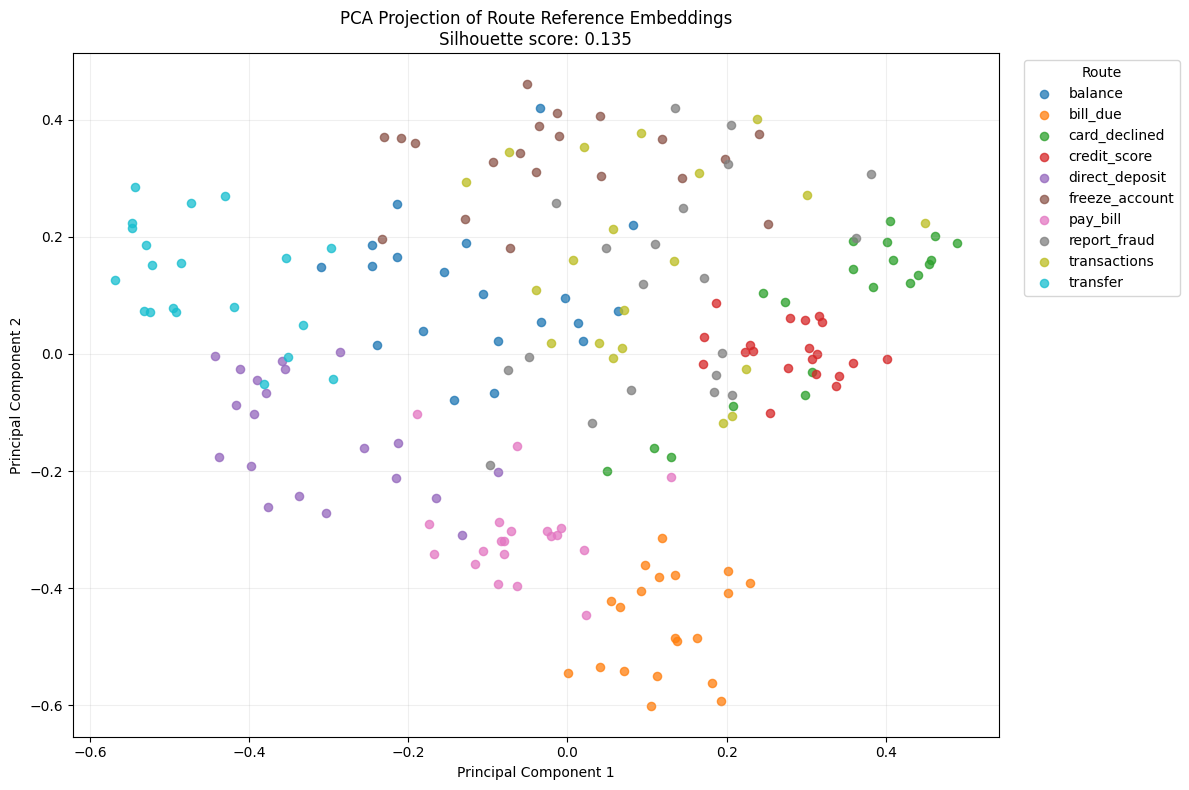

In [46]:
low_quality_routes = [
    Route(name=route_name, references=texts)
    for route_name, texts in low_quality_references.items()
]

low_quality_router = SemanticRouter(
    name='banking-low-quality-router',
    routes=low_quality_routes,
    vectorizer=vectorizer,
    redis_client=client,
    overwrite=True,
)

low_quality_router_metrics, low_quality_router_per_test_case = evaluate_classification(
    lambda text: get_router_classification(low_quality_router, text)
)

print(f"Accuracy on low quality routes: {100*low_quality_router_metrics['accuracy']:.2f}%")

fig, ax, _ = plot_route_pca(low_quality_references, vectorizer=vectorizer)
ax.plot()

### High quality route visualization

Accuracy on high quality routes: 92.67%


[]

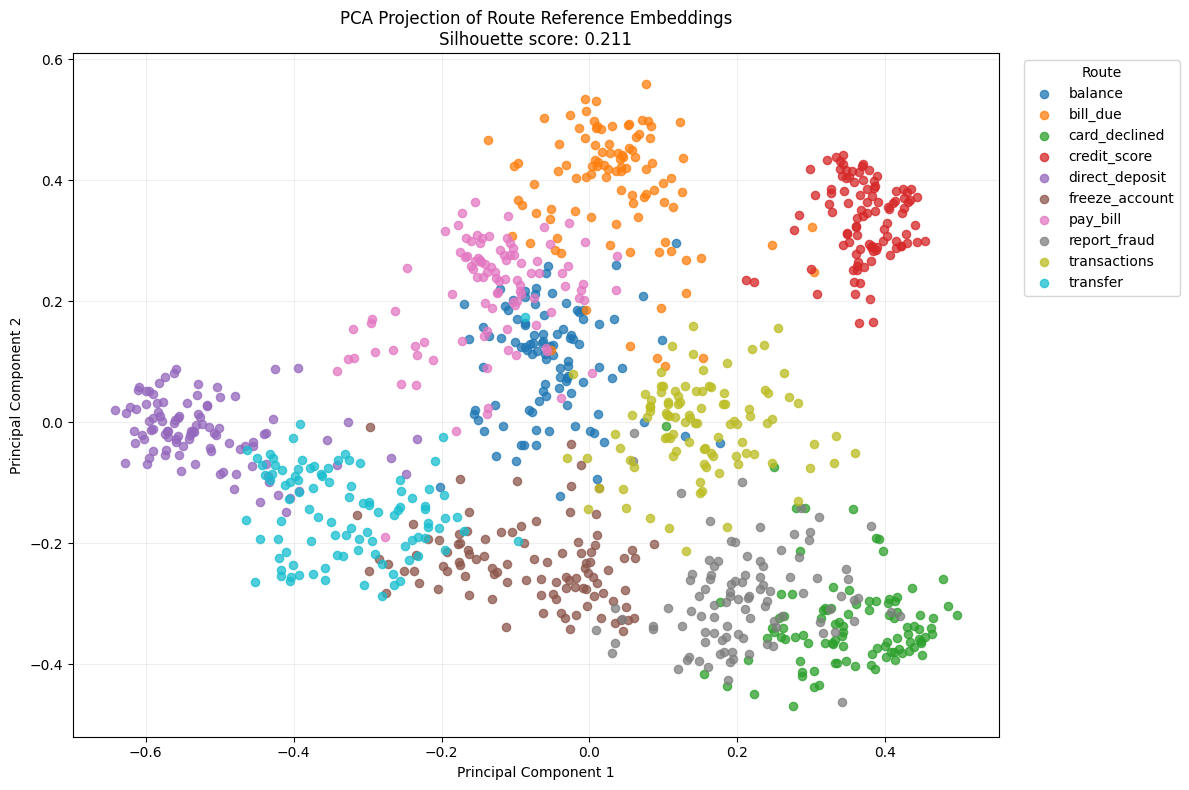

In [41]:
# We use the basic router created in Part I for this comparison
print(f"Accuracy on high quality routes: {100*basic_router_mpnet_metrics['accuracy']:.2f}%")

fig, ax, _ = plot_route_pca(train_by_intent, vectorizer=vectorizer)
ax.plot()

The high quality routes have a higher silhouette score, indicating that the route references form tighter and more distinct semantic neighbourhoods. The PCA plot supports this visuallly too. 

The semantic router would likely perform better when built with these high quality routes.

### Measuring the quality of your route references

We use this metric called **purity**(see it in action [here](https://pubs.aip.org/aip/acp/article-abstract/2431/1/080013/2906121/K-nearest-neighbor-classifier-optimization-using)) to measure the quality of our route references. For each reference, we find its `k` nearest neighbours in embedding space and check how many belong to the same route. If most neighbours have the same label, that point is pure. Conversely, if most neighbours come from other routes, it is likely that the point lies in an overlapping region, so the purity is low.

Following this definition, the overall purity is the average purity score of all the references within the router. A higher purity would suggest a better route separation, whereas a low purity indicates more overlap between routes.

NOTE: we are using kNN here as our nearest-neighbour algorithm for simplicity, but RedisVL's SemanticRouter uses HNSW (Hierarchical Navigible Small World, read more [here](https://redis.io/blog/how-hnsw-algorithms-can-improve-search/)), which is an approximate nearest neighbour algorithm. When tuned well, HNSW performs similarly to kNN, but significantly faster.

In [42]:
from sklearn.neighbors import NearestNeighbors

def compute_knn_purity(route_references, vectorizer=vectorizer, k=5):
    """
    Compute exact k-NN purity for route references using scikit-learn.

    For each reference, this function finds its `k` nearest neighbors and
    measures the fraction that belong to the same route. The final score is
    the average of those per-reference purity values.
    """
    texts = []
    labels = []

    # Flatten the route dictionary into parallel text and label lists.
    for route_name, references in route_references.items():
        for reference in references:
            texts.append(reference)
            labels.append(route_name)

    if len(texts) < 2:
        raise ValueError("At least two references are required to compute k-NN purity.")

    if len(set(labels)) < 2:
        raise ValueError("At least two routes are required to compute k-NN purity.")

    # Generate embeddings using the vectorizer
    embeddings = np.array(vectorizer.embed_many(texts), dtype=np.float32)

    k = min(k, len(texts) - 1)
    if k < 1:
        raise ValueError("`k` must be at least 1 after accounting for dataset size.")

    # Ask for k + 1 neighbors because the closest point is the point itself.
    nn = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
    nn.fit(embeddings)
    _, indices = nn.kneighbors(embeddings)

    purity_values = []

    for i, neighbors in enumerate(indices):
        source_label = labels[i]

        # Remove the self-match at position 0.
        neighbor_indices = neighbors[1:]

        same_route_count = sum(labels[j] == source_label for j in neighbor_indices)
        purity = same_route_count / k
        purity_values.append(purity)

    return float(np.mean(purity_values))


In [43]:
low_quality_knn_purity = compute_knn_purity(low_quality_references, vectorizer=vectorizer, k=5)
high_quality_knn_purity = compute_knn_purity(train_by_intent, vectorizer=vectorizer, k=5)

print(f"kNN purity on low-quality references: {low_quality_knn_purity:.3f}")
print(f"kNN purity on high-quality references: {high_quality_knn_purity:.3f}")


kNN purity on low-quality references: 0.876
kNN purity on high-quality references: 0.979


The high-quality references have a higher purity value, suggesting better separation between routes.

## Cleanup

In [44]:
client.flushall()

True